In [1]:
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output',
#                    305, basename='snapshot')
# center = snap.Cat.Group['GroupPos'][0]
# widths = np.array([1e3, 1e3, 1e3], dtype=float)

# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
# filter_length = 2.0*snap['0_Diameters']
# weight='0_Volume'
# filter_type = 'gaussian'



In [2]:
import cmasher as cmr
get_ipython().run_line_magic('matplotlib', 'widget')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

grays = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))
blues = plt.cm.Blues_r(np.linspace(0,1,10))
greens = plt.cm.Greens_r(np.linspace(0,1,10))
oranges = plt.cm.Oranges_r(np.linspace(0,1,10))

# plt.rc('font', family='serif')
# plt.rcParams['font.serif'] = 'ITC Bookman'
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 16
plt.rcParams['ytick.labelsize']= 16
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'


In [57]:
@cuda.jit(lineinfo=True)
def _gpu_power_spectrum1d(vhat, wavenum, Ngrid, Ncomplex, powerspectr):
    # vhat has shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    # Ncomplex is a tuple with the dimension
    # of the complex grid:
    # (Nx, Ny, Nz) if C2C
    # (Nx, Ny, Nz//2+1) if R2C
    
    Nx, Ny, Nz = Ngrid
    ntotal = Nx*Ny*Nz
    ncomplex_kx, ncomplex_ky, ncomplex_kz = Ncomplex
    ntotal_complex = ncomplex_kx * ncomplex_ky * ncomplex_kz
    
    ip = cuda.grid(1)

    if (ip < ntotal_complex):
        k = ip % ncomplex_kz
        ip_tmp = int((ip - k)/ncomplex_kz)
        j = ip_tmp % ncomplex_ky
        i = ip_tmp // ncomplex_ky

        power_at_freq = (vhat[i,j,k] * vhat[i,j,k].conjugate() ).real

        # this is more properly the *wavenumber*
        # (not wavevector), i.e. it says which frequency
        # bin it belongs to
        freq = int(wavenum[i,j,k] + 0.5)
        # # if we are doing a real fft
        # # we need to double to take into account
        # # energy contained in the negative KZ midplane
        # if (k > 0 and (ncomplex_kz - 1) % (Nz//2) == 0): 
        if (k > 0 and not ncomplex_kz == Nz): 
        # if (k > 0):
            power_at_freq *= 2.0

        # for spectral energy density
        cuda.atomic.add(powerspectr, (freq), 
                        power_at_freq / (ntotal**2))
        # cuda.atomic.add(powerspectr, (freq), 
        #                 power_at_freq )

@cuda.jit(lineinfo=True)
def _gpu_power_spectrum1d_finufft(vhat, wavenum, Ngrid, Ncomplex, powerspectr, M):
    # vhat has shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    # Ncomplex is a tuple with the dimension
    # of the complex grid:
    # (Nx, Ny, Nz) if C2C
    # (Nx, Ny, Nz//2+1) if R2C
    # M is the original length of the sampling points in finufft
    
    Nx, Ny, Nz = Ngrid
    ntotal = Nx*Ny*Nz
    ncomplex_kx, ncomplex_ky, ncomplex_kz = Ncomplex
    ntotal_complex = ncomplex_kx * ncomplex_ky * ncomplex_kz
    
    ip = cuda.grid(1)

    if (ip < ntotal_complex):
        k = ip % ncomplex_kz
        ip_tmp = int((ip - k)/ncomplex_kz)
        j = ip_tmp % ncomplex_ky
        i = ip_tmp // ncomplex_ky
    
        # kx =  ( i +  float(Nx) / 2.0) %  Nx  - Nx / 2 
        # ky =  ( j +  float(Ny) / 2.0) %  Ny  - Ny / 2 
        # if (ncomplex_kz == Nz//2 + 1):
        #     kz = k
        # else:
        #     kz =  ( k +  float(Nz) / 2.0) %  Nz  - Nz / 2 

        # # this is to take into account that 
        # # the widths of the region can be different
        # # but the Ny,Nz are chosen such that
        # # the spacing is uniform in all 3 directions
        # ky *= Nx / Ny
        # kz *= Nx / Nz

        power_at_freq = (vhat[i,j,k] * vhat[i,j,k].conjugate() ).real
        
        freq = int(wavenum[i,j,k] + 0.5)
        # # if we are doing a real fft
        # # we need to double to take into account
        # # energy contained in the negative KZ midplane
        if (k > 0 and (ncomplex_kz - 1) % (Nz//2) == 0): 
        # if (k > 0):
            power_at_freq *= 2.0
    
        # powerspectr[0,0,0] = i
        # cuda.atomic.add(powerspectr, (freq), 
        #                 power_at_freq / ((Nx*Ny*Nz)**2))
        cuda.atomic.add(powerspectr, (freq), 
                        power_at_freq / (M**2))
        
def power_spectrum1d_gpu(vhat, Ngrid, widths, finufft=False, M=-1, **kwargs):
    # vhat has shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    # widths is a tuple with the physical
    # size of the grid (Lx, Ly, Lz)
    Nx, Ny, Nz = Ngrid
    Ntotalcomplex = vhat.shape[0]*vhat.shape[1]*vhat.shape[2]
    if hasattr(widths, 'unit'):
        Lx, Ly, Lz = widths.value
        L_unit = widths.unit
    else:
        Lx, Ly, Lz = widths

    if (vhat.shape[2] == Nz): # complex fft
        print("complex fft")
    else: # real fft
        print("real fft")

    # wavevec should be a list of 3 3D vectors
    # vhat and KX, KY, KZ must have the same shape
    # the wavevectors here represent *physical* wavevectors
    # i.e. k = (2\pi/L)*n
    if 'wavevec' in kwargs:
        KX = kwargs['wavevec'][0]
        KY = kwargs['wavevec'][1]
        KZ = kwargs['wavevec'][2]
        assert KX.shape == KY.shape == KZ.shape == vhat.shape
    else:
        kx = 2.0*np.pi*np.fft.fftfreq(Nx, d=Lx/Nx)
        ky = 2.0*np.pi*np.fft.fftfreq(Ny, d=Ly/Ny)
        if (vhat.shape[2] == Nz): # complex fft
            kz = 2.0*np.pi*np.fft.fftfreq(Nz, d=Lz/Nz)
        else: # real fft
            kz = 2.0*np.pi*np.fft.rfftfreq(Nz, d=Lz/Nz)
        
        KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
        
    K2 = KX**2 + KY**2 + KZ**2
    
    if (finufft and M==-1):
        raise RuntimeError('The length of the original signal \
        has to be set')

    kvec = np.sqrt(KX**2 + KY**2 + KZ**2)
    # Lmin = np.min([Lx,Ly,Lz])

    kxmax = (2.0*np.pi/Lx)*(Nx//2)
    kymax = (2.0*np.pi/Ly)*(Ny//2)
    kzmax = (2.0*np.pi/Lz)*(Nz//2)

    kmax = np.sqrt(kxmax**2 + kymax**2 + kzmax**2)
    # I take the coarsest grid in k-space
    deltak = 2.0*np.pi/np.min([Lx,Ly,Lz])
    # this is to take into account that with zero-padding
    # Lx,Ly,Lz are greater but we still want to keep the
    # coarser base-grid for the power spectrum
    if 'npads' in kwargs:
        deltak *= int(kwargs['npads'])
    
    # deltak = np.sqrt((2.0*np.pi/Lx)**2 + (2.0*np.pi/Ly)**2 + (2.0*np.pi/Lz)**2 )
    # nbin = int(kmax/(2.0*np.pi/Lmin) + 0.5)
    nbin = int(kmax/deltak + 0.5)
    n1d = np.arange(0, nbin)
    # k1d = (2.0*np.pi/Lmin)*n1d
    k1d = deltak*n1d

    if hasattr(vhat, 'unit'):
        d_vhat = cp.array(vhat.value)
    else:
        d_vhat = cp.array(vhat)

    ## these are now the *wavenumbers*
    ## (not wavevectors) stored on device
    wavenum = kvec / deltak
    d_wavenum = cp.array(wavenum)  
    
    d_powerspectr = cp.zeros(k1d.shape)
    threadsperblock = 256
    blocks_1d = (Ntotalcomplex + (threadsperblock - 1)) // threadsperblock

    if not finufft:
        _gpu_power_spectrum1d[blocks_1d, threadsperblock](d_vhat, d_wavenum, (Nx, Ny, Nz), 
                                                      (vhat.shape[0], vhat.shape[1], vhat.shape[2]), 
                                                      d_powerspectr)
    else:
        _gpu_power_spectrum1d_finufft[blocks_1d, threadsperblock](d_vhat, d_wavenum, (Nx, Ny, Nz), 
                                                      (vhat.shape[0], vhat.shape[1], vhat.shape[2]), 
                                                      d_powerspectr, M)

    powerspectr = cp.asnumpy(d_powerspectr)*(Lx*Ly*Lz)*(2.0*np.pi/deltak)
    if hasattr(widths, 'unit'):
        k1d /= L_unit
        powerspectr *= L_unit**4 # (3 powers for Lx*Ly*Lz + 1 power for 1/deltak)
    if hasattr(vhat, 'unit'):
        powerspectr *= vhat.unit**2
        
        
    return powerspectr, k1d

In [4]:
import scipy.signal
def _nd_window(data, filter_function, **kwargs):
    """
    https://stackoverflow.com/questions/27345861/extending-1d-function-across-3-dimensions-for-data-windowing
    Performs an in-place windowing on N-dimensional spatial-domain data.
    This is done to mitigate boundary effects in the FFT.

    Parameters
    ----------
    data : ndarray
           Input data to be windowed, modified in place.
    filter_function : 1D window generation function
           Function should accept one argument: the window length.
           Example: scipy.signal.windows.hann
    """
    if hasattr(data, 'unit'):
        windowed_data = data.value.copy()
    else:
        windowed_data = data.copy()
    ndim_window = np.ones(data.shape)
    for axis, axis_size in enumerate(data.shape):
        # set up shape for numpy broadcasting
        filter_shape = [1, ] * data.ndim
        filter_shape[axis] = axis_size
        window = filter_function(axis_size, **kwargs).reshape(filter_shape)
        # scale the window intensities to maintain image intensity
        # np.power(window, (1.0/data.ndim), out=window)
        # window = window**(1.0/data.ndim)
        windowed_data *= window
        ndim_window *= window
    
    if hasattr(data, 'unit'):
        windowed_data *= data.unit_quantity
        
    return windowed_data, ndim_window

In [5]:
# fixed seed for reproducibility
rng = np.random.default_rng(seed=456789)

In [6]:
Nx, Ny, Nz = 256, 256, 256
# Lx, Ly, Lz = 2.0*np.pi, 2.0*np.pi, 2.0*np.pi
# Lx, Ly, Lz = 2.0*np.pi, np.pi, 4.0*np.pi
Lx, Ly, Lz = 1., 1., 1.

kx = 2.0*np.pi*np.fft.fftfreq(Nx, d=Lx/Nx)
ky = 2.0*np.pi*np.fft.fftfreq(Ny, d=Ly/Ny)
kz = 2.0*np.pi*np.fft.rfftfreq(Nz, d=Lz/Nz)

KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')

K2 = KX**2 + KY**2 + KZ**2

# this is for reproducibility
phases_rho = 2.0*np.pi*rng.uniform(low=-1.0, high=1.0, size=(Nx,Ny,Nz//2+1))

K2min = (2.0*np.pi/Lx)**2 + (2.0*np.pi/Ly)**2 + (2.0*np.pi/Lz)**2
K2max = 100*K2min
power_law_exponent = -5./3.
# energy per 3D mode \times k^2 = E(k) \sim k^power_law_exponent
# ==> energy per 3D mode \sim k^[(power_law_exponent-2)/2]
ampl = np.zeros(K2.shape)
ampl = np.where((K2>=K2min)*(K2<K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)
ampl = np.where((K2>K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.))*np.exp(-(K2-K2max)/K2max),ampl)

# amplitudes_rho = ampl*np.exp(1j*phases_rho)
hat_den = (Nx*Ny*Nz)*ampl*np.exp(1j*phases_rho)/(Lx*Ly*Lz)
# hat_den = np.sqrt((Nx*Ny*Nz))*ampl*np.exp(1j*phases_rho)
# hat_den = ampl*np.exp(1j*phases_rho)

/tmp/ipykernel_3861322/1743528749.py:23: RuntimeWarning: divide by zero encountered in power
  ampl = np.where((K2>=K2min)*(K2<K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)
/tmp/ipykernel_3861322/1743528749.py:24: RuntimeWarning: divide by zero encountered in power
  ampl = np.where((K2>K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.))*np.exp(-(K2-K2max)/K2max),ampl)


In [7]:
ampl.max()

1.0

In [8]:
hat_den.shape

(256, 256, 129)

In [58]:
# don't need this anymore with real transforms
# hat_den = enforce_hermitian(amplitudes_rho)

density_cartesian = np.fft.irfftn(hat_den)
hat_den = np.fft.rfftn(density_cartesian)
powerspectr, k1d = power_spectrum1d_gpu(hat_den, (Nx,Ny,Nz), (Lx,Ly,Lz))

real fft


/groups/astro/lperrone/.local/lib/python3.10/site-packages/numba/core/lowering.py:112: NumbaDebugInfoWarning: Could not find source for function: <function _gpu_power_spectrum1d at 0x7f19d55cd000>. Debug line information may be inaccurate.
  warnings.warn(NumbaDebugInfoWarning(msg))


In [59]:
powerspectr

array([9.16720109e-36, 2.28755475e-33, 3.96471206e+00, 1.70048574e+00,
       1.43550290e+00, 1.06176790e+00, 6.67906353e-01, 5.41152918e-01,
       4.29350202e-01, 4.11623753e-01, 3.04566773e-01, 2.53555634e-01,
       2.33681239e-01, 2.08076293e-01, 1.81991564e-01, 1.49650130e-01,
       1.51067730e-01, 1.32131628e-01, 1.02879782e-01, 6.92232197e-02,
       5.16951503e-02, 3.70584127e-02, 2.45572659e-02, 1.71628218e-02,
       1.16719616e-02, 8.15422475e-03, 5.35758679e-03, 3.45122180e-03,
       2.30170720e-03, 1.46468682e-03, 9.29765979e-04, 5.96507266e-04,
       3.63649380e-04, 2.31387971e-04, 1.41040195e-04, 8.24075424e-05,
       5.03560712e-05, 2.91424860e-05, 1.70397275e-05, 9.57389824e-06,
       5.58518782e-06, 3.13857982e-06, 1.68390554e-06, 9.39825807e-07,
       4.95711505e-07, 2.71956374e-07, 1.37597838e-07, 7.27664901e-08,
       3.79526281e-08, 1.92262200e-08, 9.56240549e-09, 4.61411488e-09,
       2.30483201e-09, 1.10205221e-09, 5.18103530e-10, 2.43878622e-10,
      

In [10]:
np.sqrt(np.mean(np.square(density_cartesian)))

8.742587654684645

## This is Parseval theorem
#### https://en.wikipedia.org/wiki/Parseval%27s_theorem

#### https://en.wikipedia.org/wiki/Spectral_density#Power_spectral_density

### Note: the following was for the for the "backward" FFT normalization as defined in Numpy

In theory the Parseval theorem can be stated as:
np.sum(density_cartesian^2) = np.sum(powerspectr)/(Nx \times Ny \times Nz)
when in the definition of the powerspectr we have that
power_at_freq = (vhat[i,j,k] \times vhat[i,j,k].conjugate() ).real

The disadvantage of this formulation is that (for a given real field) when we double the sampling resolution
there is now 2^2 amount of energy at any given freq (2^6 in 3D)

In [11]:
# np.sum(density_cartesian**2), np.sum(powerspectr)/(Nx*Ny*Nz)

### With the "orthonormal" FFT normalization it is all much nicer!

If we use the orthonormal FFT normalization and compute the spectral energy "density" as 
power_at_freq = (vhat[i,j,k] \times vhat[i,j,k].conjugate() ).real
then the Parseval theorem can be stated as:
np.sum(density_cartesian^2) = np.sum(powerspectr) = np.sum(power_at_freq)

Or, equivalently: np.mean(density_cartesian^2) = np.mean(power_at_freq)

In [12]:
np.mean(density_cartesian**2), np.sum(powerspectr)

(76.43283889984434, 76.43283889984423)

In [47]:
def parseval_theorem(scalar_field, widths, powerspectrum):
    Nx, Ny, Nz = scalar_field.shape
    Lx, Ly, Lz = widths
    voxel = (Lx/Nx)*(Ly/Ny)*(Lz/Nz)
    volume_average = np.sum(scalar_field*np.conj(scalar_field)*voxel)/(Lx*Ly*Lz)
    print("Volume average of scalar field: ", volume_average)
    print("Total power: ", np.sum(powerspectrum))
    # if hasattr(scalar_field, 'unit'):

In [48]:
parseval_theorem(density_cartesian, (Lx,Ly,Lz), powerspectr)

Volume average of scalar field:  76.43283889984434
Total power:  76.43283889984423


In [52]:
hat_den_c = np.fft.fftn(density_cartesian)

In [53]:
np.sum(np.abs(hat_den_c)**2)/(Nx*Ny*Nz)**2

76.43283889984421

In [54]:
np.sum(np.abs(hat_den_c)**2)

2.1513931549262972e+16

In [56]:
np.sum(density_cartesian**2)/(Nx*Ny*Nz)

76.43283889984434

# Need to rewrite it in terms of integral in k space!!!

In [41]:
e,f,g=density_cartesian.shape

In [43]:
e

256

In [13]:
# this does not work because with real fft one has to 
# double the energy in the plane k>0
# np.sum(np.abs(hat_den)**2)/(Nx*Ny*Nz)

In [14]:


# xUniform = np.linspace(-Lx/2, Lx/2, Nx)
# yUniform = np.linspace(-Ly/2, Ly/2, Ny)
# zUniform = np.linspace(-Lz/2, Lz/2, Nz)

# XXUniform, YYUniform, ZZUniform = np.meshgrid(xUniform, yUniform, zUniform, sparse=False, indexing='ij')

# density_cartesian = finufft.nufft3d2(XXUniform.flatten(), YYUniform.flatten(), ZZUniform.flatten(), 
#                              amplitudes_rho, eps=1e-06, isign=-1) 
# density_cartesian = np.real(density_cartesian.reshape((Nx,Ny,Nz)))

In [15]:
# hat_den = np.fft.rfftn(density_cartesian)

# powerspectr, k1d = power_spectrum1d_gpu(KX, KY, KZ, hat_den, (Nx,Ny,Nz), Lx)

In [16]:
# we select a non-periodic cut of the full-periodic box
Nx_cut = 64
Ny_cut = 64
Nz_cut = 64

Lx_cut = Lx*Nx_cut/Nx
Ly_cut = Ly*Ny_cut/Ny
Lz_cut = Lz*Nz_cut/Nz

density_cartesian_cut = density_cartesian[10:10+Nx_cut,15:15+Ny_cut,22:22+Nz_cut]

hat_den_cut = np.fft.rfftn(density_cartesian_cut)

# kx_cut = np.fft.fftfreq(size_cut, d=1.0/Nx)
# ky_cut = np.fft.fftfreq(size_cut, d=1.0/Ny)
# kz_cut = np.fft.rfftfreq(size_cut, d=1.0/Nz)

# KX_cut, KY_cut, KZ_cut = np.meshgrid(kx_cut, ky_cut, kz_cut, indexing='ij')

# powerspectr_cut, k1d_cut = power_spectrum1d_gpu(KX_cut, KY_cut, KZ_cut, hat_den_cut, 
#                                                 (size_cut,size_cut,size_cut), Lx)

powerspectr_cut, k1d_cut = power_spectrum1d_gpu(hat_den_cut, (Nx_cut,Ny_cut,Nz_cut), 
                                                (Lx_cut,Ly_cut,Lz_cut))

real fft


In [17]:
np.mean(density_cartesian_cut**2), np.sum(powerspectr_cut)

(62.7376217254283, 62.753046984836814)

In [18]:
np.sum(density_cartesian_cut**2)/(Nx_cut*Ny_cut*Nz_cut)

62.7376217254283

In [37]:
# # now the cut with zero-padding

npads = 2
hat_den_cut_zeropadded = np.fft.rfftn(density_cartesian_cut, 
                                    s=(npads*Nx_cut,npads*Ny_cut,npads*Nz_cut)) 

# kx_pad = np.fft.fftfreq(npads*size_cut, d=1.0/Nx)
# ky_pad = np.fft.fftfreq(npads*size_cut, d=1.0/Nx)
# kz_pad = np.fft.rfftfreq(npads*size_cut, d=1.0/Nx)

# KX_pad, KY_pad, KZ_pad = np.meshgrid(kx_pad, ky_pad, kz_pad, indexing='ij')
# powerspectr_padded, k1d_padded = power_spectrum1d_gpu(KX_pad, KY_pad, KZ_pad,
#                                                       hat_den_cut_zeropadded/np.sqrt(npads**3), 
#                                                       (size_cut,size_cut,size_cut), Lx)

# powerspectr_padded, k1d_padded = power_spectrum1d_gpu(hat_den_cut_zeropadded/np.sqrt(npads**3), 
#                                                       (npads*Nx_cut,npads*Ny_cut,npads*Nz_cut), 
#                                                         (npads*Lx_cut,npads*Ly_cut,npads*Lz_cut))
# powerspectr_padded, k1d_padded = power_spectrum1d_gpu(hat_den_cut_zeropadded*np.sqrt(npads**3), 
#                                                       (npads*Nx_cut,npads*Ny_cut,npads*Nz_cut), 
#                                                         (npads*Lx_cut,npads*Ly_cut,npads*Lz_cut))
powerspectr_padded, k1d_padded = power_spectrum1d_gpu(hat_den_cut_zeropadded*np.sqrt(npads**3), 
                                                      (npads*Nx_cut,npads*Ny_cut,npads*Nz_cut), 
                                                        (npads*Lx_cut,npads*Ly_cut,npads*Lz_cut), npads=2)

real fft


In [26]:
hat_den_cut_zeropadded.shape

(128, 128, 65)

In [27]:
np.sum(density_cartesian_cut**2)/(npads**3*Nx_cut*Ny_cut*Nz_cut), np.sum(powerspectr_padded)

(7.842202715678537, 125.49066871026507)

In [28]:
np.sum(powerspectr_cut)/np.sum(powerspectr_padded)

0.5000614597864809

In [29]:
powerspectr_cut.shape

(56,)

In [30]:
# this is the cut density
# but windowed by the hann window
density_cartesian_cut_hann, ndim_window = _nd_window(density_cartesian_cut, 
                                             scipy.signal.windows.hann)

hat_den_cut_hann = np.fft.rfftn(density_cartesian_cut_hann)
powerspectr_hann, k1d_hann = power_spectrum1d_gpu(hat_den_cut_hann, (Nx_cut,Ny_cut,Nz_cut), 
                                                (Lx_cut,Ly_cut,Lz_cut))

powerspectr_hann /= np.sum(np.square(ndim_window))/(Nx_cut*Ny_cut*Nz_cut)

real fft


In [31]:
# # this is the cut density
# # but windowed by the cosine window
# density_cartesian_cut_cosine, ndim_window = _nd_window(density_cartesian_cut, 
#                                              scipy.signal.windows.cosine)

# hat_den_cut_cosine = np.fft.rfftn(density_cartesian_cut_cosine)
# powerspectr_cosine, k1d_cosine = power_spectrum1d_gpu(KX_cut, KY_cut, KZ_cut, hat_den_cut_cosine, 
#                                                 (size_cut,size_cut,size_cut), Lx)

# powerspectr_cosine /= np.sum(np.square(ndim_window))/(size_cut*size_cut*size_cut)


In [32]:
# # this is the cut density
# # but windowed by the chebyschev window
# density_cartesian_cut_cheb, ndim_window = _nd_window(density_cartesian_cut, 
#                                              scipy.signal.windows.chebwin, at=50.)

# hat_den_cut_cheb = np.fft.rfftn(density_cartesian_cut_cheb)
# powerspectr_cheb, k1d_cheb = power_spectrum1d_gpu(KX_cut, KY_cut, KZ_cut, hat_den_cut_cheb, 
#                                                 (size_cut,size_cut,size_cut), Lx)

# powerspectr_cheb /= np.sum(np.square(ndim_window))/(size_cut*size_cut*size_cut)


In [33]:
# this is the cut density
# but windowed by the kaiser window
density_cartesian_cut_kaiser, ndim_window = _nd_window(density_cartesian_cut, 
                                             scipy.signal.windows.kaiser, beta=14.)

hat_den_cut_kaiser = np.fft.rfftn(density_cartesian_cut_kaiser)
powerspectr_kaiser, k1d_kaiser = power_spectrum1d_gpu(hat_den_cut_kaiser, (Nx_cut,Ny_cut,Nz_cut), 
                                                (Lx_cut,Ly_cut,Lz_cut))

powerspectr_kaiser /= np.sum(np.square(ndim_window))/(Nx_cut*Ny_cut*Nz_cut)


real fft


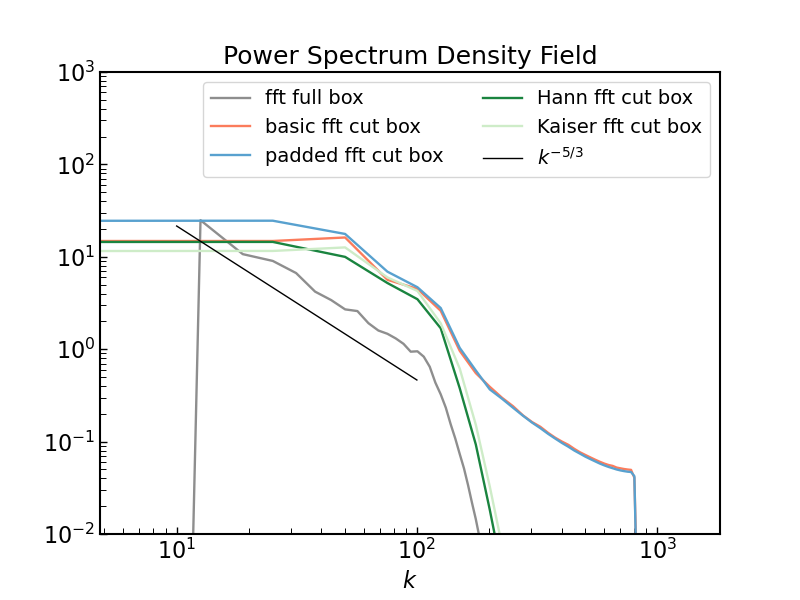

In [38]:
fig, ax = plt.subplots(figsize=(8,6))

tt = np.logspace(1,2, 100)

ax.plot(k1d, powerspectr, ls='-', color=grays[5],
        markerfacecolor='none', markersize=4, label=r'fft full box')

ax.plot(k1d_cut, powerspectr_cut, ls='-', color=reds[5],
        markerfacecolor='none', markersize=4, label=r'basic fft cut box')

ax.plot(k1d_padded, powerspectr_padded, ls='-', color=blues[4],
        markerfacecolor='none', markersize=4, label=r'padded fft cut box')

ax.plot(k1d_hann, powerspectr_hann, ls='-', color=greens[2],
        markerfacecolor='none', markersize=4, label=r'Hann fft cut box')

# ax.plot(k1d_cosine, powerspectr_cosine, ls='-', color=greens[4],
#         markerfacecolor='none', markersize=4, label=r'Cosine fft cut box')

# ax.plot(k1d_cheb, powerspectr_cheb, ls='-', color=greens[7],
#         markerfacecolor='none', markersize=4, label=r'Chebyshev fft cut box')

ax.plot(k1d_kaiser, powerspectr_kaiser, ls='-', color=greens[7],
        markerfacecolor='none', markersize=4, label=r'Kaiser fft cut box')


ax.plot(tt, 1e3*tt**(-5./3.), ls='-', color='k',lw=1., label=r'$k^{-5/3}$')

ax.set_xlabel('$k$', fontsize=16)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc='best',ncols=2,fontsize=14)

ax.set_title(r'Power Spectrum Density Field', fontsize=18)
# ax.set_xlabel((1/arepo_length).to('1/Mpc').label('k'),fontsize=16)
# ax.set_ylabel(r'$E_B(k)$',fontsize=16)
# ax.set_title('Magnetic energy',fontsize=18)

# ax.set_ylim(ymin=1e-25)
ax.set_ylim(ymin=1e-2, ymax=1e3)
# ax[1].set_xlim(xmax=30)

plt.savefig('../plots/better_power_spectrum_full_box_cut_box.pdf',dpi=400)
plt.show()


In [ ]:
# dens_cart = density_cartesian[:,:,0]
dens_cart_cut = density_cartesian_cut[:,:,int(Nz_cut//2)-1]
dens_cart_hann = density_cartesian_cut_hann[:,:,int(Nz_cut//2)-1]

vmax = np.max(dens_cart_cut)
vmin = -vmax
# print(vmin)
# print(vmax)
# norm = LogNorm(vmin=vmin,vmax=vmax)
norm = Normalize(vmin=vmin,vmax=vmax)
# cmap = cmr.fall
cmap = cmr.fusion

fig, axes = plt.subplots(1,2, figsize=(8,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_cart_cut, origin='lower', norm=norm, cmap=cmap)

im2 = axes[1].imshow(
    dens_cart_hann, origin='lower', norm=norm, cmap=cmap)

axes[0].set_title('original')
axes[1].set_title('windowed')

for i in range(2):
    axes[i].set_xlabel('x')

axes[0].set_ylabel('y')



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(r'$\rho$')

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(r'$\rho$')

fig.subplots_adjust(top=0.85,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Density field (original and windowed)',y=0.95)
# plt.savefig('../plots/cut_box_original_windowed.pdf',dpi=400)
# plt.close()